# DenseNet121 WeightedRandomSampler + AdamW

Model setting:

- Backbone: DenseNet121
- Pretrained weights: ImageNet
- Loss function: CrossEntropyLoss
- Imbalance strategy: WeightedRandomSampler
- Optimizer: AdamW
- Learning rate: 1e-4
- Batch size: 32
- Max epochs: 30
- Early stopping patience: 7
- Best model selection: validation QWK


In [1]:
EXPERIMENT_NAME = "densenet121_weighted_sampler_adamw"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 30
PATIENCE = 7
MONITOR_METRIC = "qwk"

print("Experiment:", EXPERIMENT_NAME)


Experiment: densenet121_weighted_sampler_adamw


In [2]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent

elif (current_path / "data").exists() and (current_path / "models").exists():
    PROJECT_ROOT = current_path

else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models folder exists:", (PROJECT_ROOT / "models").exists())
print("densenet.py exists:", (PROJECT_ROOT / "models" / "densenet.py").exists())
print("utils folder exists:", (PROJECT_ROOT / "utils").exists())
print("train_utils.py exists:", (PROJECT_ROOT / "utils" / "train_utils.py").exists())


Current path: D:\760-Group1-main\wanqian
Project root: D:\760-Group1-main
models folder exists: True
densenet.py exists: True
utils folder exists: True
train_utils.py exists: True


In [3]:
import torch
import torch.nn as nn

from models.densenet import get_densenet121, count_trainable_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

# Stage 1: freeze DenseNet feature extractor
for param in model.features.parameters():
    param.requires_grad = False

trainable_params, total_params = count_trainable_parameters(model)

print("Stage 1: classifier-only training")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Device: cpu
Stage 1: classifier-only training
Trainable parameters: 5,125
Total parameters:     6,958,981


In [4]:
# dataloader
# dataloader + WeightedRandomSampler

from utils.dataset import get_dataloaders, print_dataset_info
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import torch

SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

# Create WeightedRandomSampler for training set only
train_labels = [label for _, label in train_dataset.samples]

class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / class_counts

sample_weights = [class_weights[label] for label in train_labels]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

print("Class counts:", class_counts)
print("Sampler class weights:", class_weights)
print("WeightedRandomSampler train_loader created.")


Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']
Class counts: [316 308 134 122 144]
Sampler class weights: [0.00316456 0.00324675 0.00746269 0.00819672 0.00694444]
WeightedRandomSampler train_loader created.


In [5]:
# loss and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: AdamW")

Loss function: CrossEntropyLoss
Optimizer: AdamW


## create densenet

In [6]:
from utils.train_utils import train_model

SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=MAX_EPOCHS,
    save_path=SAVE_PATH,
    monitor_metric=MONITOR_METRIC,
    patience=PATIENCE,
    min_delta=1e-4,
)

history_df.tail()





Epoch 1/30
------------------------------------------------------------


D:\760-Group1-main\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 1.6497 | Train Acc: 0.2188 | Train Macro F1: 0.2128 | Train QWK: 0.0165
Val Loss:   1.5668 | Val Acc:   0.3562 | Val Macro F1: 0.2593 | Val QWK:   0.1818 | Val MAE:   1.1096
New best model found at epoch 1.
Best val qwk: 0.1818
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_weighted_sampler_adamw.pth

Epoch 2/30
------------------------------------------------------------


...

D:\760-Group1-main\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 1.2788 | Train Acc: 0.4873 | Train Macro F1: 0.4773 | Train QWK: 0.5570
Val Loss:   1.2249 | Val Acc:   0.5205 | Val Macro F1: 0.4481 | Val QWK:   0.6040 | Val MAE:   0.8356
No improvement in val qwk. Patience: 5/7


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
25,26,1.328774,1.234783,25,0,0.465820,0.454081,0.457437,0.910156,0.522434,...,0.467390,0.496906,0.808219,0.605110,70,38,32,0.479452,0.260274,0.219178
26,27,1.303143,1.247645,25,1,0.484375,0.477291,0.480482,0.863281,0.550879,...,0.457817,0.486309,0.842466,0.606683,71,36,35,0.486301,0.246575,0.239726
27,28,1.298160,1.233359,25,2,0.474609,0.459206,0.463186,0.901367,0.557644,...,0.439187,0.460660,0.876712,0.586237,73,38,35,0.500000,0.260274,0.239726
28,29,1.286852,1.238914,25,3,0.491211,0.481867,0.482301,0.925781,0.520431,...,0.462769,0.484578,0.863014,0.592229,72,36,36,0.493151,0.246575,0.246575
29,30,1.278807,1.224934,25,4,0.487305,0.477317,0.479454,0.874023,0.556970,...,0.448073,0.489511,0.835616,0.603989,70,35,35,0.479452,0.239726,0.239726


In [7]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

print("Saved history to:", history_path)
history_df

Saved history to: D:\760-Group1-main\outputs\results\densenet121_weighted_sampler_adamw_history.csv


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
0,1,1.649695,1.566756,0,0,0.218750,0.212822,0.214164,1.583008,0.016454,...,0.259319,0.287207,1.109589,0.181841,94,53,41,0.643836,0.363014,0.280822
1,2,1.626928,1.566159,1,0,0.254883,0.252560,0.252678,1.474609,0.056083,...,0.273697,0.276546,1.143836,0.232479,101,60,41,0.691781,0.410959,0.280822
2,3,1.615968,1.525461,2,0,0.248047,0.242910,0.243896,1.451172,0.068394,...,0.249536,0.285299,1.171233,0.140178,98,55,43,0.671233,0.376712,0.294521
3,4,1.584269,1.516123,2,1,0.264648,0.259883,0.260542,1.378906,0.132939,...,0.292105,0.314097,1.164384,0.233702,98,54,44,0.671233,0.369863,0.301370
4,5,1.571200,1.486229,4,0,0.267578,0.268477,0.268768,1.361328,0.193313,...,0.317436,0.336119,1.068493,0.302324,93,54,39,0.636986,0.369863,0.267123
5,6,1.544353,1.479981,5,0,0.305664,0.301866,0.302780,1.290039,0.213335,...,0.365743,0.367403,0.979452,0.431961,89,52,37,0.609589,0.356164,0.253425
6,7,1.543644,1.446915,6,0,0.306641,0.303315,0.306679,1.275391,0.279051,...,0.349549,0.373000,1.075342,0.419063,90,48,42,0.616438,0.328767,0.287671
7,8,1.503664,1.450519,6,1,0.331055,0.324263,0.327509,1.230469,0.308820,...,0.353821,0.355711,1.047945,0.467492,91,49,42,0.623288,0.335616,0.287671
8,9,1.501078,1.428922,8,0,0.333984,0.327980,0.331907,1.226562,0.306178,...,0.390165,0.409830,1.020548,0.479080,85,44,41,0.582192,0.301370,0.280822
9,10,1.476955,1.405284,9,0,0.362305,0.353197,0.353989,1.146484,0.379435,...,0.371792,0.397379,1.034247,0.455505,86,44,42,0.589041,0.301370,0.287671


## best epoch 

In [8]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])



Best epoch based on validation QWK:
epoch                  25.000000
val_loss                1.245501
val_accuracy            0.541096
val_macro_f1            0.491046
val_weighted_f1         0.519593
val_mae                 0.787671
val_qwk                 0.610391
val_adjacent_errors    35.000000
val_distant_errors     32.000000
Name: 24, dtype: float64


## train model

save history

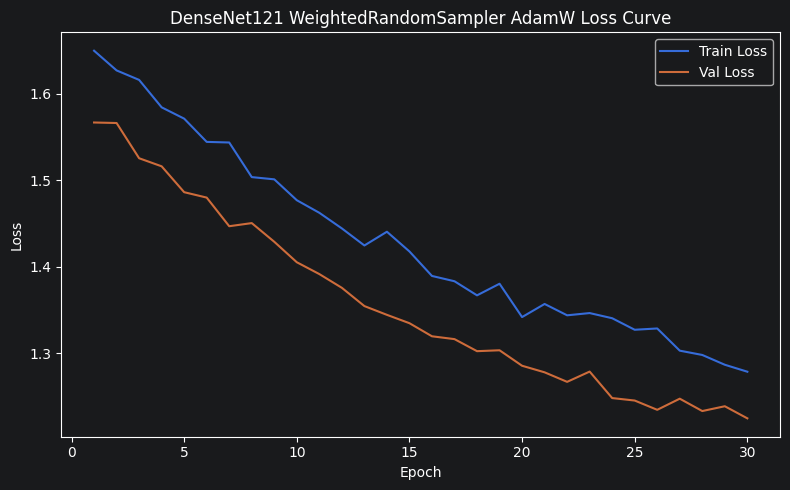

Saved figure to: D:\760-Group1-main\outputs\figures\densenet121_weighted_sampler_adamw_loss.png


In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 WeightedRandomSampler AdamW Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_loss.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [10]:
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics
# train set
val_loss, val_metrics, val_true, val_pred = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device,
)

print_metrics(val_metrics, title="Validation Metrics")


Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Validation Metrics
accuracy: 0.5411
macro_f1: 0.4910
weighted_f1: 0.5196
mae: 0.7877
qwk: 0.6104
total_errors: 67
adjacent_errors: 35
distant_errors: 32
total_error_rate: 0.4589
adjacent_error_rate: 0.2397
distant_error_rate: 0.2192


In [12]:
from utils.metrics import get_classification_report

class_names = ["0Normal", "1Doubtful", "2Mild", "3Moderate", "4Severe"]
# test set
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print_metrics(test_metrics, title="Test Metrics")


#classification report 
report = get_classification_report(
    y_true=test_true,
    y_pred=test_pred,
    class_names=class_names,
)

print(report)


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Test Metrics
accuracy: 0.4898
macro_f1: 0.4396
weighted_f1: 0.4700
mae: 0.8571
qwk: 0.5617
total_errors: 150
adjacent_errors: 86
distant_errors: 64
total_error_rate: 0.5102
adjacent_error_rate: 0.2925
distant_error_rate: 0.2177
              precision    recall  f1-score   support

     0Normal       0.52      0.63      0.57        91
   1Doubtful       0.47      0.48      0.47        88
       2Mild       0.23      0.08      0.12        38
   3Moderate       0.48      0.43      0.45        35
     4Severe       0.54      0.64      0.59        42

    accuracy                           0.49       294
   macro avg       0.45      0.45      0.44       294
weighted avg       0.46      0.49      0.47       294



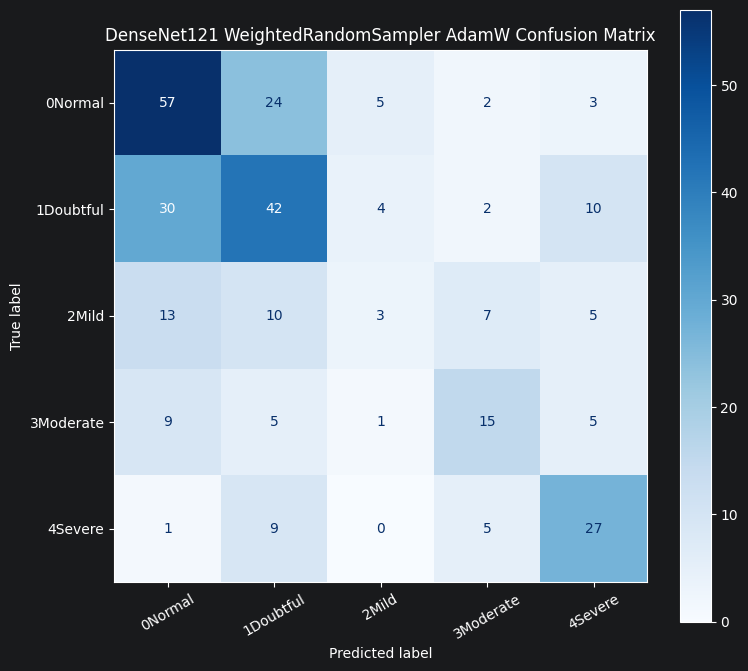

Saved figure to: D:\760-Group1-main\outputs\figures\densenet121_weighted_sampler_adamw_confusion_matrix.png


In [13]:
# Confusion matrix
from utils.metrics import get_confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 WeightedRandomSampler AdamW Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_confusion_matrix.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)
